In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("noida_room_price_prediction_dataset.csv")
df.head()

,Sector,BHK,Area_sqft,Bathrooms,Floor,Furnished,Metro_Distance_km,Price_Lakh
0,Sector 93A,2,2031,3,17,Unfurnished,7.18,121.09
1,Sector 128,3,991,4,19,Unfurnished,1.18,71.69
2,Sector 135,1,2434,1,1,Unfurnished,7.89,139.20
3,Sector 18,1,1411,1,4,Semi-Furnished,3.39,77.58
4,Sector 76,3,2306,3,9,Unfurnished,5.17,148.60


In [3]:
df.drop_duplicates()

,Sector,BHK,Area_sqft,Bathrooms,Floor,Furnished,Metro_Distance_km,Price_Lakh
0,Sector 93A,2,2031,3,17,Unfurnished,7.18,121.09
1,Sector 128,3,991,4,19,Unfurnished,1.18,71.69
2,Sector 135,1,2434,1,1,Unfurnished,7.89,139.20
3,Sector 18,1,1411,1,4,Semi-Furnished,3.39,77.58
4,Sector 76,3,2306,3,9,Unfurnished,5.17,148.60
...,...,...,...,...,...,...,...,...
495,Sector 50,1,1036,2,9,Furnished,5.16,75.42
496,Sector 76,2,555,3,23,Semi-Furnished,3.81,56.58
497,Sector 78,3,1542,4,10,Semi-Furnished,6.44,100.86
498,Sector 50,3,2355,3,19,Unfurnished,0.79,165.11


In [4]:
df.isnull().sum()

Sector               0
BHK                  0
Area_sqft            0
Bathrooms            0
Floor                0
Furnished            0
Metro_Distance_km    0
Price_Lakh           0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sector             500 non-null    str    
 1   BHK                500 non-null    int64  
 2   Area_sqft          500 non-null    int64  
 3   Bathrooms          500 non-null    int64  
 4   Floor              500 non-null    int64  
 5   Furnished          500 non-null    str    
 6   Metro_Distance_km  500 non-null    float64
 7   Price_Lakh         500 non-null    float64
dtypes: float64(2), int64(4), str(2)
memory usage: 41.6 KB


In [6]:
df.describe

<bound method NDFrame.describe of          Sector  BHK  Area_sqft  Bathrooms  Floor       Furnished  \
0    Sector 93A    2       2031          3     17     Unfurnished   
1    Sector 128    3        991          4     19     Unfurnished   
2    Sector 135    1       2434          1      1     Unfurnished   
3     Sector 18    1       1411          1      4  Semi-Furnished   
4     Sector 76    3       2306          3      9     Unfurnished   
..          ...  ...        ...        ...    ...             ...   
495   Sector 50    1       1036          2      9       Furnished   
496   Sector 76    2        555          3     23  Semi-Furnished   
497   Sector 78    3       1542          4     10  Semi-Furnished   
498   Sector 50    3       2355          3     19     Unfurnished   
499  Sector 150    4       2357          5      9       Furnished   

     Metro_Distance_km  Price_Lakh  
0                 7.18      121.09  
1                 1.18       71.69  
2                 7.89    

# Average Price by Sector

In [8]:
df.groupby("Sector")["Price_Lakh"].mean().sort_values()

Sector
Sector 135     99.424681
Sector 137    102.339375
Sector 128    102.684808
Sector 50     104.066000
Sector 62     105.623696
Sector 93A    107.566000
Sector 18     107.913621
Sector 78     111.112391
Sector 76     111.754706
Sector 150    118.301404
Name: Price_Lakh, dtype: float64

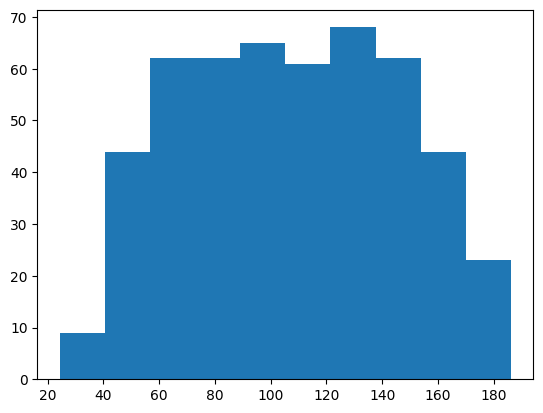

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["Price_Lakh"])
plt.show()

# Sector-wise Price

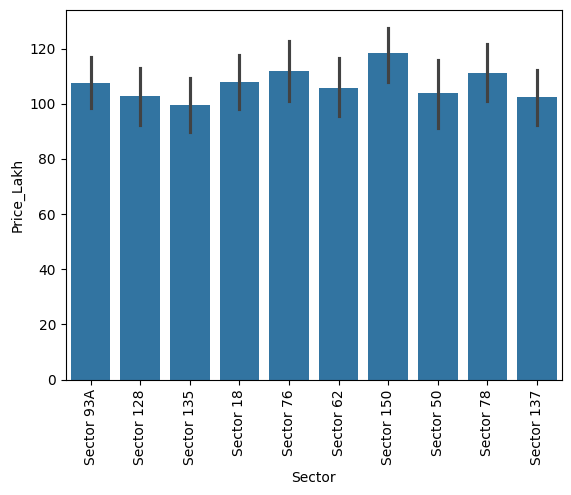

In [10]:
import seaborn as sns

sns.barplot(x="Sector", y="Price_Lakh", data=df)
plt.xticks(rotation=90)
plt.show()

# BHK vs Price

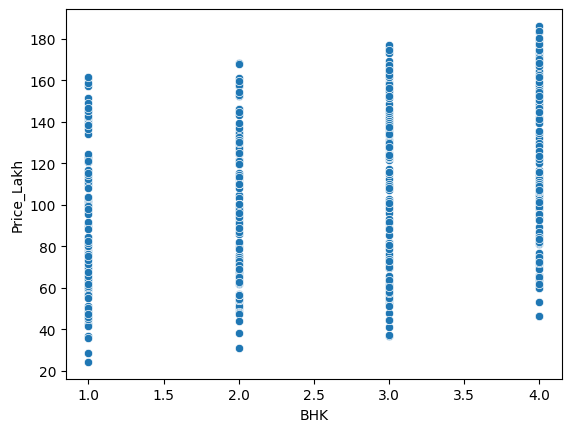

In [11]:
sns.scatterplot(x="BHK", y="Price_Lakh", data=df)
plt.show()

# Feature Engineering Convert text columns to numbers:

In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Sector"]=le.fit_transform(df["Sector"])
df["Furnished"]=le.fit_transform(df["Furnished"])

In [13]:
df.head()

,Sector,BHK,Area_sqft,Bathrooms,Floor,Furnished,Metro_Distance_km,Price_Lakh
0,9,2,2031,3,17,2,7.18,121.09
1,0,3,991,4,19,2,1.18,71.69
2,1,1,2434,1,1,2,7.89,139.20
3,4,1,1411,1,4,1,3.39,77.58
4,7,3,2306,3,9,2,5.17,148.60


In [14]:
df

,Sector,BHK,Area_sqft,Bathrooms,Floor,Furnished,Metro_Distance_km,Price_Lakh
0,9,2,2031,3,17,2,7.18,121.09
1,0,3,991,4,19,2,1.18,71.69
2,1,1,2434,1,1,2,7.89,139.20
3,4,1,1411,1,4,1,3.39,77.58
4,7,3,2306,3,9,2,5.17,148.60
...,...,...,...,...,...,...,...,...
495,5,1,1036,2,9,0,5.16,75.42
496,7,2,555,3,23,1,3.81,56.58
497,8,3,1542,4,10,1,6.44,100.86
498,5,3,2355,3,19,2,0.79,165.11


In [15]:
# Seprate dataset
X=df.drop("Price_Lakh" ,axis=1)
y=(df["Price_Lakh"])

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [17]:
from sklearn.ensemble import RandomForestRegressor
Rf=RandomForestRegressor(n_estimators=10, random_state=42)
Rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [18]:
predictions = Rf.predict(X_test)

In [19]:
predictions

array([169.113, 176.91 , 129.193,  52.779, 124.849,  75.247,  76.743,
       103.313, 137.646,  69.205, 150.378,  74.657, 100.37 ,  91.396,
       115.436,  67.131,  71.69 , 137.134, 161.342,  55.074, 121.382,
       130.121,  77.862, 111.234, 141.872, 127.731, 116.238,  78.995,
        68.259, 111.794,  50.895, 103.27 , 105.921, 166.311, 155.399,
       130.335, 156.27 , 115.421,  83.571, 143.208, 116.914, 113.859,
       117.679,  85.938, 118.35 ,  65.441, 119.057, 140.962, 106.24 ,
       139.136, 155.463,  73.365, 143.34 ,  51.544, 117.786, 122.592,
        78.772, 142.355, 178.734, 111.977, 137.388, 151.479, 117.001,
       173.271, 114.262,  65.374, 125.413,  58.196,  87.199,  66.542,
        53.221,  57.891, 137.704,  74.609, 137.46 , 163.724,  55.696,
       139.055, 145.802,  69.251, 153.526,  73.108, 119.491, 171.098,
       152.195, 122.585, 163.38 ,  71.107, 101.569,  47.958, 109.581,
        49.689, 129.747,  64.106, 114.129,  44.063, 130.954, 114.072,
       153.306,  54.

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error
print("R2_score",r2_score(y_test, predictions))
print("mean_absolute_error",mean_absolute_error(y_test, predictions))

R2_score 0.9436467236934594
mean_absolute_error 7.866529999999999


In [24]:
import pickle
pickle.dump(Rf,open("nrpp.pkl","wb"))
print("pickle file is saved")

pickle file is saved
